In [10]:
import random
import torch

import clip
import utils
import data_utils
import similarity

import matplotlib
from matplotlib import pyplot as plt

## Settings

In [11]:
clip_name = 'ViT-B/16'
target_name = 'resnet50'
target_layer = 'layer4'
d_probe = 'imagenet_broden'
concept_set = 'data/3k.txt'
batch_size = 16
device = 'cuda'
pool_mode = 'avg'

save_dir = 'saved_activations'
similarity_fn = similarity.soft_wpmi

## Run CLIP-Dissect

In [12]:
utils.save_activations(clip_name = clip_name, target_name = target_name, target_layers = [target_layer], 
                       d_probe = d_probe, concept_set = concept_set, batch_size = batch_size, 
                       device = device, pool_mode=pool_mode, save_dir = save_dir)

In [13]:
save_names = utils.get_save_names(clip_name = clip_name, target_name = target_name,
                                  target_layer = target_layer, d_probe = d_probe,
                                  concept_set = concept_set, pool_mode=pool_mode,
                                  save_dir = save_dir)

target_save_name, clip_save_name, text_save_name = save_names

similarities, target_feats = utils.get_similarity_from_activations(target_save_name, clip_save_name, 
                                                             text_save_name, similarity_fn)

with open(concept_set, 'r') as f: 
    words = (f.read()).split('\n')

pil_data = data_utils.get_data(d_probe)

100%|██████████| 2048/2048 [05:10<00:00,  6.59it/s]

torch.Size([2048, 3000])


## Visualize Results


 Layer:layer4 Neuron:858
1st description: furniture, sim:2.071
2nd description: cabin, sim:1.762
3rd description: porch, sim:1.674
5 most highly activating images in D_probe:


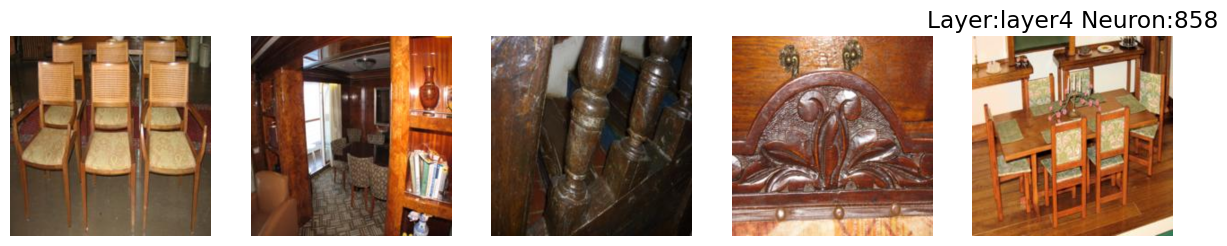


 Layer:layer4 Neuron:53
1st description: meter, sim:0.810
2nd description: clock, sim:0.525
3rd description: gas, sim:0.471
5 most highly activating images in D_probe:


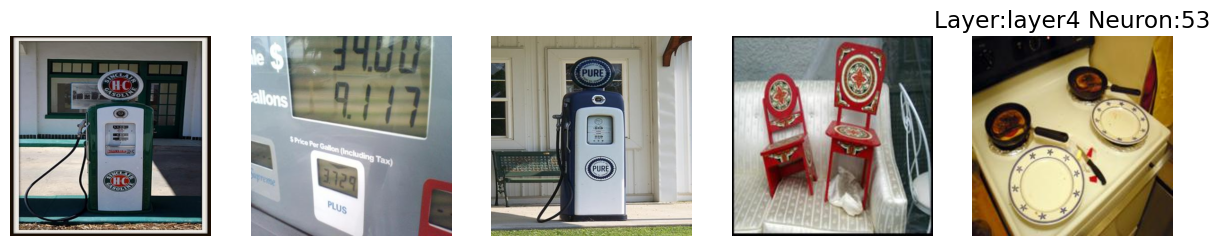


 Layer:layer4 Neuron:1687
1st description: sink, sim:3.008
2nd description: bathroom, sim:2.611
3rd description: shower, sim:1.951
5 most highly activating images in D_probe:


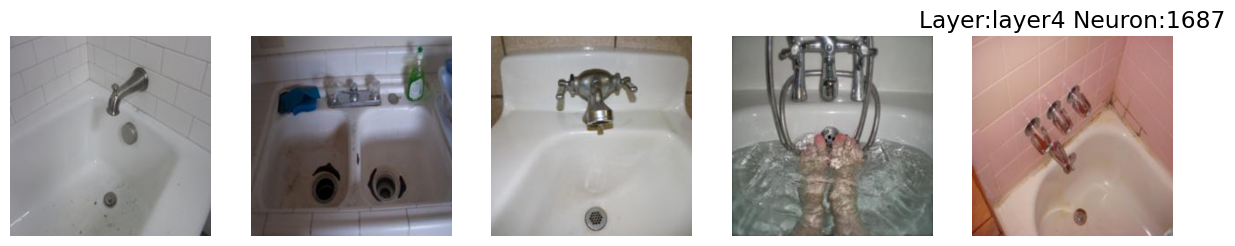


 Layer:layer4 Neuron:369
1st description: blue, sim:1.147
2nd description: pool, sim:0.632
3rd description: pile, sim:0.580
5 most highly activating images in D_probe:


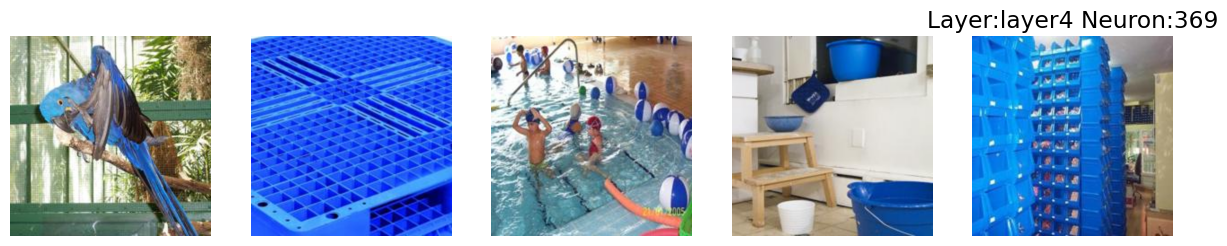


 Layer:layer4 Neuron:1747
1st description: mountain, sim:2.312
2nd description: mount, sim:1.648
3rd description: summit, sim:1.597
5 most highly activating images in D_probe:


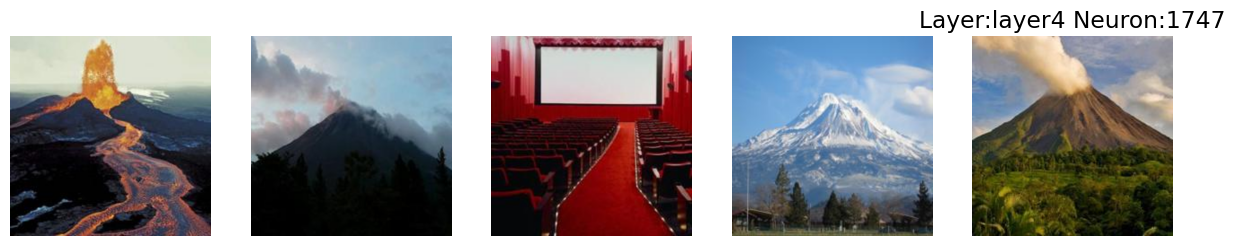


 Layer:layer4 Neuron:831
1st description: habitat, sim:1.423
2nd description: tree, sim:1.265
3rd description: wood, sim:1.104
5 most highly activating images in D_probe:


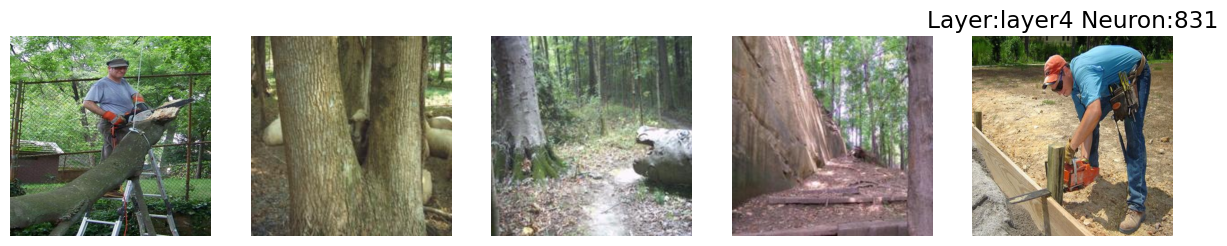


 Layer:layer4 Neuron:762
1st description: golf, sim:2.755
2nd description: grass, sim:1.481
3rd description: ball, sim:1.367
5 most highly activating images in D_probe:


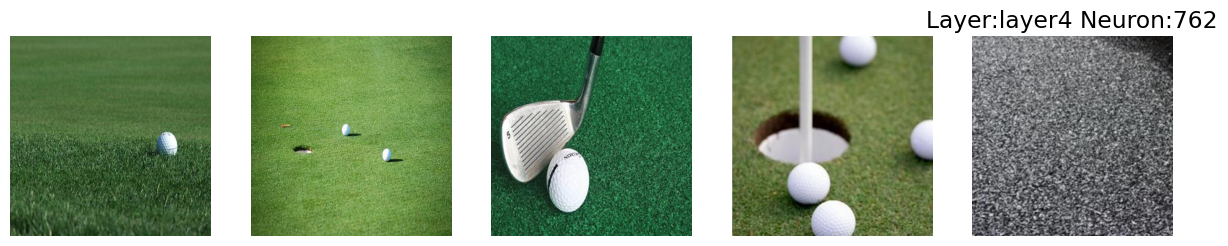


 Layer:layer4 Neuron:735
1st description: shoe, sim:0.740
2nd description: shop, sim:0.675
3rd description: display, sim:0.578
5 most highly activating images in D_probe:


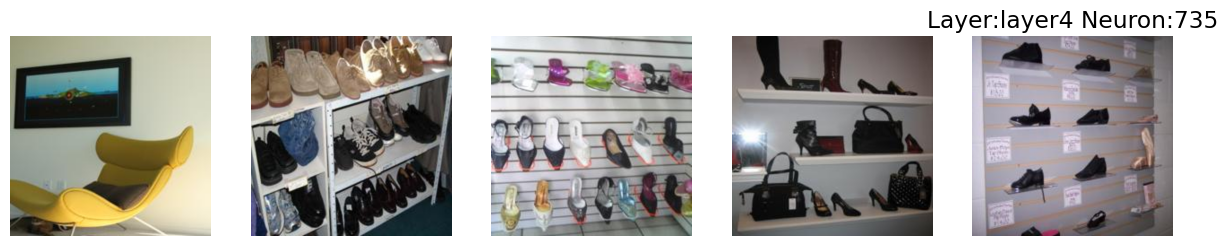


 Layer:layer4 Neuron:1199
1st description: shower, sim:1.151
2nd description: bathroom, sim:1.015
3rd description: room, sim:0.644
5 most highly activating images in D_probe:


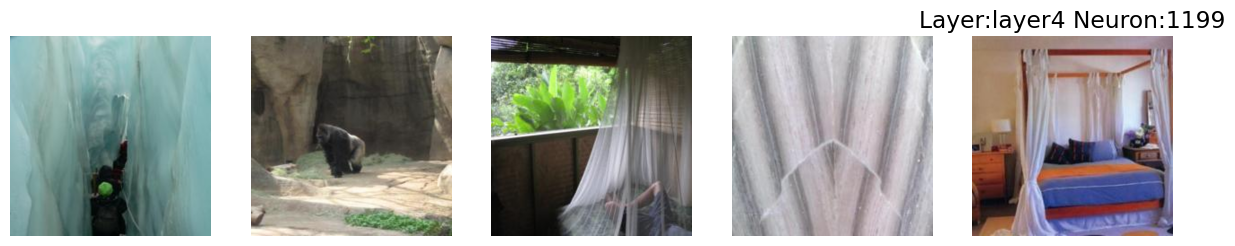


 Layer:layer4 Neuron:381
1st description: skin, sim:1.173
2nd description: regard, sim:0.995
3rd description: makeup, sim:0.964
5 most highly activating images in D_probe:


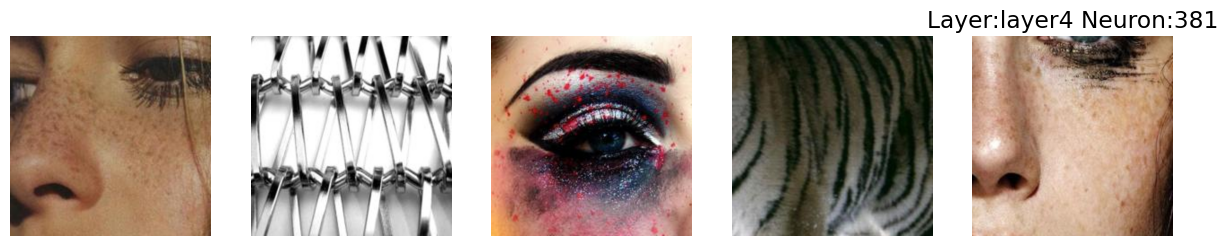

In [14]:
neurons_to_check = ids_to_check = random.sample([i for i in range(target_feats.shape[1])], k=10)
#neurons_to_check = torch.sort(torch.max(similarities, dim=1)[0], descending=True)[1][0:10]

ranks = ["1st", "2nd", "3rd"]
top_vals, top_ids = torch.topk(target_feats, k=5, dim=0)

for orig_id in ids_to_check:

    print('\n Layer:{} Neuron:{}'.format(target_layer, (int(orig_id))))
    vals, ids = torch.topk(similarities[orig_id], k=3, largest=True)
    for i in range(len(vals)):
        print("{} description: {}, sim:{:.3f}".format(ranks[i], words[int(ids[i])], vals[i]))
    
    print("5 most highly activating images in D_probe:")
    fig = plt.figure(figsize=(15, 7))
    for i, top_id in enumerate(top_ids[:, orig_id]):
        im, label = pil_data[top_id]
        im = im.resize([375,375])
        fig.add_subplot(1, 5, i+1)
        plt.imshow(im)
        plt.axis('off')
        
    plt.title('Layer:{} Neuron:{}'.format(target_layer, (int(orig_id))))
    plt.show()

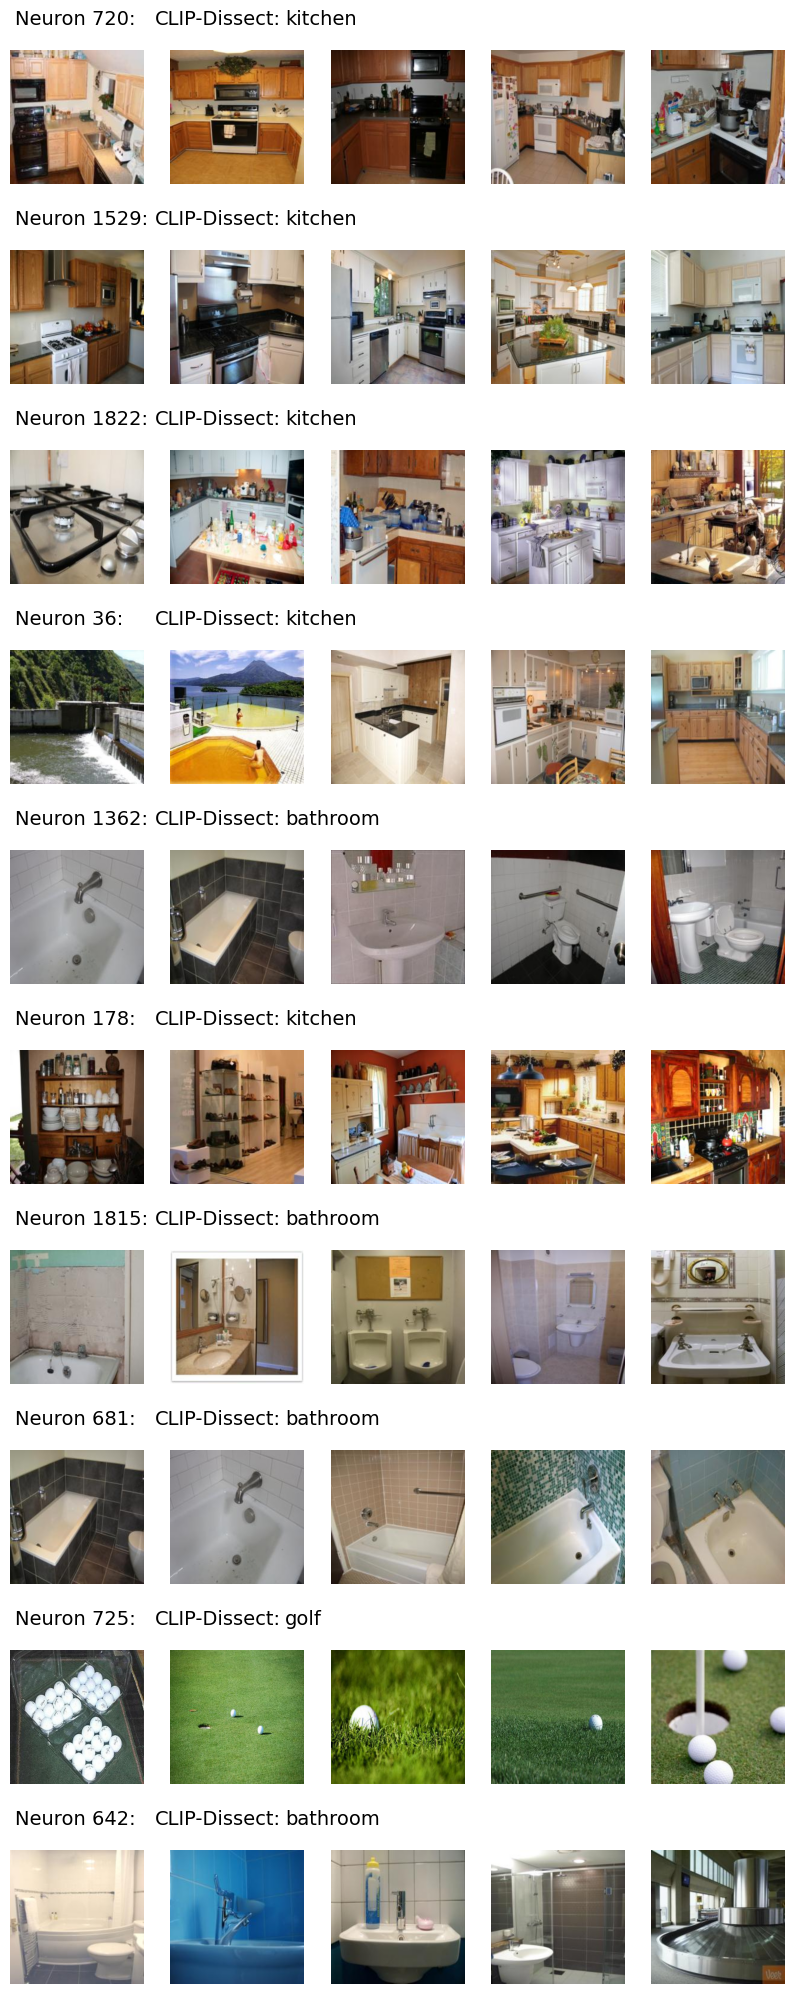

In [15]:
neurons_to_check = torch.sort(torch.max(similarities, dim=1)[0], descending=True)[1][0:10]
font_size=14
font = {'size'   : font_size}

matplotlib.rc('font', **font)

fig = plt.figure(figsize=[10, len(neurons_to_check)*2])#constrained_layout=True)
subfigs = fig.subfigures(nrows=len(neurons_to_check), ncols=1)
for j, orig_id in enumerate(neurons_to_check):
    vals, ids = torch.topk(similarities[orig_id], k=5, largest=True)
        
    subfig = subfigs[j]
    subfig.text(0.13, 0.96, "Neuron {}:".format(int(orig_id)), size=font_size)
    subfig.text(0.27, 0.96, "CLIP-Dissect:", size=font_size)
    subfig.text(0.4, 0.96, words[int(ids[0])], size=font_size)
    axs = subfig.subplots(nrows=1, ncols=5)
    for i, top_id in enumerate(top_ids[:, orig_id]):
        im, label = pil_data[top_id]
        im = im.resize([375,375])
        axs[i].imshow(im)
        axs[i].axis('off')
plt.show()